In [41]:
# 1. Carga de Librerías y Dataset
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# El CSV está ubicado en la misma carpeta que este notebook
csv_path = os.path.join(os.getcwd(), 'datos_concatenados.csv')
df_raw = pd.read_csv(csv_path)
print(f'Dataset cargado exitosamente: {df_raw.shape[0]:,} filas.')

# Base para el preprocesamiento posterior
df_clean = df_raw.copy()

Dataset cargado exitosamente: 72,740 filas.


In [42]:
df_algebra_lineal = df_clean[
    df_clean['Asignatura'].astype(str).str.strip().eq('ALGEBRA LINEAL')
].copy()

print('La celda se ejecuto correctamente.')
print(f'Registros encontrados: {len(df_algebra_lineal):,}')
print(f"Estudiantes unicos: {df_algebra_lineal['ALUMNO_ID'].nunique():,}")


La celda se ejecuto correctamente.
Registros encontrados: 1,980
Estudiantes unicos: 1,664


In [43]:
df_anho_semestre = df_algebra_lineal.groupby(['Anho', 'Semestre']).agg({'ALUMNO_ID': 'nunique'}).reset_index()

In [45]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================

df_algebra_lineal = df_algebra_lineal.copy()

# Convertir variables a numérico
for col in ['Primer.Par', 'Segundo.Par', 'Firma']:
    df_algebra_lineal[col] = pd.to_numeric(
        df_algebra_lineal[col],
        errors='coerce'
    )

# Variable objetivo
df_algebra_lineal['Aprobado'] = (
    df_algebra_lineal['Firma'] > 50
).astype(int)

print("✅ Variable objetivo creada: Aprobado")
print(df_algebra_lineal['Aprobado'].value_counts())
print(df_algebra_lineal['Aprobado'].value_counts(normalize=True))

✅ Variable objetivo creada: Aprobado
Aprobado
0    1454
1     526
Name: count, dtype: int64
Aprobado
0    0.734343
1    0.265657
Name: proportion, dtype: float64


In [46]:
# Promedio de los parciales
df_algebra_lineal['Promedio_Parciales'] = (
    df_algebra_lineal['Primer.Par'] +
    df_algebra_lineal['Segundo.Par']
) / 2

# Diferencia entre parciales
df_algebra_lineal['Mejora_Parcial'] = (
    df_algebra_lineal['Segundo.Par'] -
    df_algebra_lineal['Primer.Par']
)

In [47]:
# Orden temporal
df_algebra_lineal['Periodo'] = (
    df_algebra_lineal['Anho'].astype(int) * 10 +
    df_algebra_lineal['Semestre'].astype(int)
)

df_algebra_lineal = df_algebra_lineal.sort_values(
    ['ALUMNO_ID', 'Periodo']
).copy()

grupo = df_algebra_lineal.groupby('ALUMNO_ID', group_keys=False)

# ¿Ya había cursado anteriormente?
df_algebra_lineal['Veces_Anteriores'] = grupo.cumcount()

df_algebra_lineal['Tomo_Anteriormente'] = (
    df_algebra_lineal['Veces_Anteriores'] > 0
).astype(int)

# Promedio histórico de parciales, SOLO períodos anteriores
df_algebra_lineal['Promedio_Historico'] = (
    grupo['Promedio_Parciales']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Tasa histórica de aprobación, SOLO períodos anteriores
df_algebra_lineal['Tasa_Aprobacion_Historica'] = (
    grupo['Aprobado']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Sin historial → 0
df_algebra_lineal['Promedio_Historico'] = (
    df_algebra_lineal['Promedio_Historico'].fillna(0)
)

df_algebra_lineal['Tasa_Aprobacion_Historica'] = (
    df_algebra_lineal['Tasa_Aprobacion_Historica'].fillna(0)
)

In [48]:
features = [
    'Primer.Par',
    'Segundo.Par',
    'Promedio_Parciales',
    'Mejora_Parcial',
    'Promedio_Historico',
    'Tasa_Aprobacion_Historica',
    'Tomo_Anteriormente'
]

X = df_algebra_lineal[features].copy()
y = df_algebra_lineal['Aprobado'].copy()

print("X:", X.shape)
print("y:", y.shape)
print("\nDistribución del objetivo:")
print(y.value_counts())

X: (1980, 7)
y: (1980,)

Distribución del objetivo:
Aprobado
0    1454
1     526
Name: count, dtype: int64


In [49]:
print("\n" + "=" * 60)
print("CONTROL DE VARIABLES")
print("=" * 60)

print("\nVariables:")
print(X.columns.tolist())

print("\nValores nulos:")
print(X.isnull().sum())

print("\nResumen:")
print(X.describe().T)


CONTROL DE VARIABLES

Variables:
['Primer.Par', 'Segundo.Par', 'Promedio_Parciales', 'Mejora_Parcial', 'Promedio_Historico', 'Tasa_Aprobacion_Historica', 'Tomo_Anteriormente']

Valores nulos:
Primer.Par                   0
Segundo.Par                  0
Promedio_Parciales           0
Mejora_Parcial               0
Promedio_Historico           0
Tasa_Aprobacion_Historica    0
Tomo_Anteriormente           0
dtype: int64

Resumen:
                            count       mean        std   min   25%    50%  \
Primer.Par                 1980.0  42.093434  24.038937   0.0  27.0  44.00   
Segundo.Par                1980.0  31.382323  25.752540   0.0   0.0  31.00   
Promedio_Parciales         1980.0  36.737879  22.878924   0.0  20.0  37.75   
Mejora_Parcial             1980.0 -10.711111  19.706522 -71.0 -23.0  -9.00   
Promedio_Historico         1980.0   5.922222  14.315580   0.0   0.0   0.00   
Tasa_Aprobacion_Historica  1980.0   0.048485   0.214843   0.0   0.0   0.00   
Tomo_Anteriormente   

In [50]:
# =============================================================================
# 4. TRAIN / TEST SPLIT
# =============================================================================



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST")
print("=" * 60)

print(f"Train: {X_train.shape[0]:,} registros")
print(f"Test:  {X_test.shape[0]:,} registros")

print("\nProporción de aprobados:")
print(f"Train: {y_train.mean():.2%}")
print(f"Test:  {y_test.mean():.2%}")

TRAIN / TEST
Train: 1,584 registros
Test:  396 registros

Proporción de aprobados:
Train: 26.58%
Test:  26.52%


In [51]:
# =============================================================================
# 5. REGRESIÓN LOGÍSTICA
# =============================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=2000
    ))
])

modelo_logistico.fit(X_train, y_train)

print("✅ Modelo de Regresión Logística entrenado correctamente.")

✅ Modelo de Regresión Logística entrenado correctamente.


In [52]:
# Predicciones
y_pred = modelo_logistico.predict(X_test)

# Probabilidad de aprobar
y_proba = modelo_logistico.predict_proba(X_test)[:, 1]

print("Predicciones generadas correctamente.")
print(f"Predicciones: {len(y_pred)}")

Predicciones generadas correctamente.
Predicciones: 396


In [53]:
# =============================================================================
# 6. EVALUACIÓN
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 60)
print("📊 RESULTADOS - REGRESIÓN LOGÍSTICA")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No aprobado', 'Aprobado']
))

📊 RESULTADOS - REGRESIÓN LOGÍSTICA
Accuracy : 0.7904
Precision: 0.5671
Recall   : 0.8857
F1-Score : 0.6914
AUC-ROC  : 0.8824

Classification Report:
              precision    recall  f1-score   support

 No aprobado       0.95      0.76      0.84       291
    Aprobado       0.57      0.89      0.69       105

    accuracy                           0.79       396
   macro avg       0.76      0.82      0.77       396
weighted avg       0.85      0.79      0.80       396



In [54]:
# =============================================================================
# 7. MATRIZ DE CONFUSIÓN
# =============================================================================

cm = confusion_matrix(y_test, y_pred)

print("=" * 60)
print("MATRIZ DE CONFUSIÓN")
print("=" * 60)
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nVerdaderos Negativos : {tn}")
print(f"Falsos Positivos    : {fp}")
print(f"Falsos Negativos    : {fn}")
print(f"Verdaderos Positivos: {tp}")

MATRIZ DE CONFUSIÓN
[[220  71]
 [ 12  93]]

Verdaderos Negativos : 220
Falsos Positivos    : 71
Falsos Negativos    : 12
Verdaderos Positivos: 93


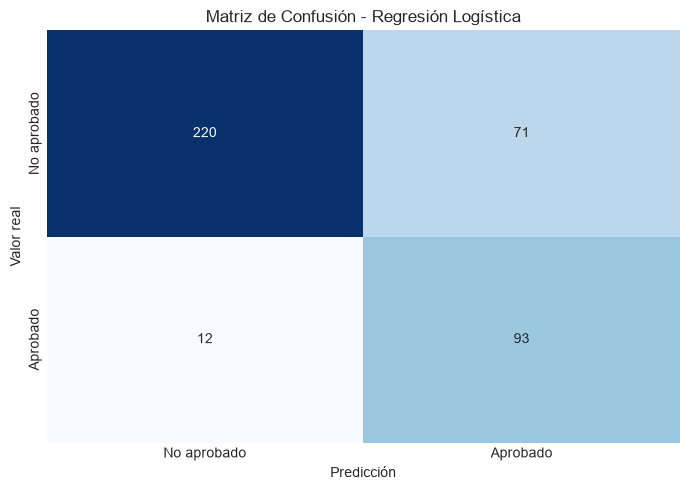

In [55]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No aprobado', 'Aprobado'],
    yticklabels=['No aprobado', 'Aprobado']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()

In [56]:
coef = modelo_logistico.named_steps['modelo'].coef_[0]

coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coef
})

coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])

coef_df = coef_df.sort_values(
    'Coeficiente',
    ascending=False
)

print("=" * 60)
print("COEFICIENTES DE LA REGRESIÓN LOGÍSTICA")
print("=" * 60)
print(coef_df.to_string(index=False))

COEFICIENTES DE LA REGRESIÓN LOGÍSTICA
                 Variable  Coeficiente  Odds_Ratio
       Promedio_Parciales     0.975468    2.652408
              Segundo.Par     0.947439    2.579097
               Primer.Par     0.837794    2.311263
           Mejora_Parcial     0.214015    1.238642
Tasa_Aprobacion_Historica     0.137959    1.147928
       Tomo_Anteriormente     0.015435    1.015555
       Promedio_Historico    -0.683010    0.505094


In [57]:
# =============================================================================
# 5. REGRESIÓN LINEAL
# =============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Variables disponibles antes del resultado final
features_lineal = [
    'Primer.Par',
    'Segundo.Par',
    'Promedio_Parciales',
    'Mejora_Parcial',
    'Promedio_Historico',
    'Tasa_Aprobacion_Historica',
    'Tomo_Anteriormente'
]

X_lineal = df_algebra_lineal[features_lineal].copy()
y_lineal = df_algebra_lineal['Firma'].copy()

# Eliminar registros donde falten datos para este modelo
mask = X_lineal.notna().all(axis=1) & y_lineal.notna()

X_lineal = X_lineal.loc[mask]
y_lineal = y_lineal.loc[mask]

print("=" * 60)
print("REGRESIÓN LINEAL")
print("=" * 60)
print(f"Registros utilizados: {len(X_lineal):,}")
print(f"Variables predictoras: {len(features_lineal)}")
print(f"Variable objetivo: Firma")

REGRESIÓN LINEAL
Registros utilizados: 1,536
Variables predictoras: 7
Variable objetivo: Firma


In [58]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lineal,
    y_lineal,
    test_size=0.20,
    random_state=42
)

print(f"Entrenamiento: {len(X_train_lin):,}")
print(f"Prueba: {len(X_test_lin):,}")

Entrenamiento: 1,228
Prueba: 308


In [59]:
modelo_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])

modelo_lineal.fit(X_train_lin, y_train_lin)

y_pred_lin = modelo_lineal.predict(X_test_lin)

r2 = r2_score(y_test_lin, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test_lin, y_pred_lin))
mae = mean_absolute_error(y_test_lin, y_pred_lin)

print("=" * 60)
print("RESULTADOS - REGRESIÓN LINEAL")
print("=" * 60)
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

RESULTADOS - REGRESIÓN LINEAL
R²   : 0.6441
RMSE : 16.3312
MAE  : 12.0581


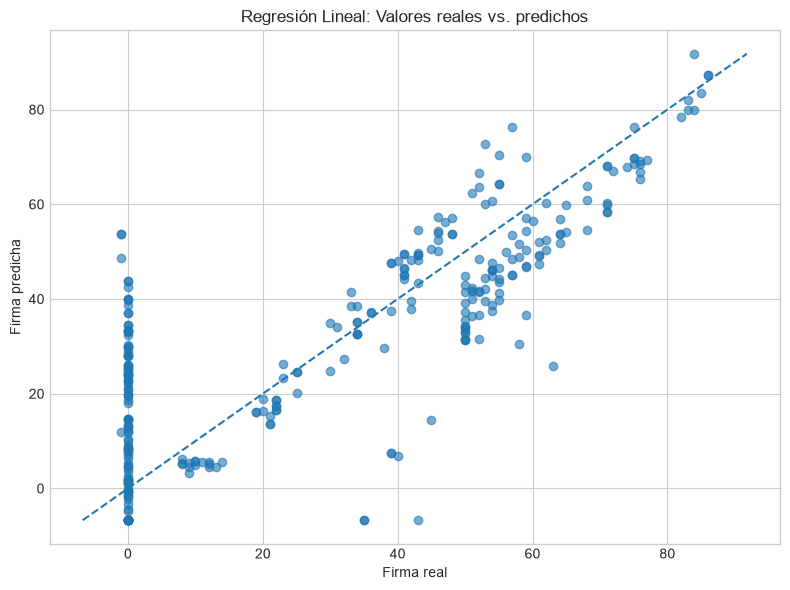

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_lin,
    y_pred_lin,
    alpha=0.6
)

min_val = min(y_test_lin.min(), y_pred_lin.min())
max_val = max(y_test_lin.max(), y_pred_lin.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Firma real')
plt.ylabel('Firma predicha')
plt.title('Regresión Lineal: Valores reales vs. predichos')
plt.tight_layout()
plt.show()

In [61]:
coef_lin = modelo_lineal.named_steps['modelo'].coef_

coef_lin_df = pd.DataFrame({
    'Variable': X_train_lin.columns,
    'Coeficiente_Lineal': coef_lin
})

coef_lin_df = coef_lin_df.sort_values(
    'Coeficiente_Lineal',
    ascending=False
)

print("=" * 60)
print("COEFICIENTES - REGRESIÓN LINEAL")
print("=" * 60)
print(coef_lin_df.to_string(index=False))

COEFICIENTES - REGRESIÓN LINEAL
                 Variable  Coeficiente_Lineal
              Segundo.Par            9.347928
       Promedio_Parciales            9.153722
               Primer.Par            7.514820
       Tomo_Anteriormente            5.738896
           Mejora_Parcial            3.206192
Tasa_Aprobacion_Historica            0.614011
       Promedio_Historico           -1.523959


In [65]:
# =============================================================================
# 6. PREPROCESAMIENTO DE CARRERA
# =============================================================================

# Mapeo de códigos de carrera a nombres legibles
career_code_mapping = {
    'CIV-PLS13': 'Ing. Civil',
    'CIV-PLS23': 'Ing. Civil',
    'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil',
    'INT9ORTERR': 'Ing. Civil',
    'INT9SANEHI': 'Ing. Civil',

    'ELE-PLS13': 'Ing. Electromecánica',
    'ELE-PLS23': 'Ing. Electromecánica',
    'INT9ELECTR': 'Ing. Electromecánica',
    'INT9SDIGYT': 'Ing. Electromecánica',

    'MCT-PLS13': 'Ing. Mecatrónica',
    'MCT-PLS23': 'Ing. Mecatrónica',
    'MCT9-OPT': 'Ing. Mecatrónica',

    'IND-PLS13': 'Ing. Industrial',
    'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial',
    'INT9-PROYT': 'Ing. Industrial',

    'CGF-PLS13': 'Ing. Geográfica',
    'CGF-PLS23': 'Ing. Geográfica',
    'INT9RNYMA': 'Ing. Geográfica',

    'MEC-PLS13': 'Ing. Mecánica',
    'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica',
    'MEC9-OPT': 'Ing. Mecánica',

    'ECA-PLS13': 'Ing. Electrónica',
    'ECA-PLS23': 'Ing. Electrónica',
    'ECA9-OPT': 'Ing. Electrónica'
}

# Trabajamos sobre nuestro dataset de Álgebra Lineal
df_algebra_lineal = df_algebra_lineal.copy()

# Normalizar código y realizar el mapeo
df_algebra_lineal['Cod.Car.Sec'] = (
    df_algebra_lineal['Cod.Car.Sec']
    .astype('string')
    .str.strip()
)

df_algebra_lineal['Carrera_Nombre'] = (
    df_algebra_lineal['Cod.Car.Sec']
    .map(career_code_mapping)
)

print("=" * 60)
print("PREPROCESAMIENTO DE CARRERA")
print("=" * 60)

print(f"Registros antes del filtro: {len(df_algebra_lineal):,}")

# Ver códigos que no pudieron mapearse
codigos_sin_mapear = (
    df_algebra_lineal.loc[
        df_algebra_lineal['Carrera_Nombre'].isna(),
        'Cod.Car.Sec'
    ]
    .value_counts()
)

if len(codigos_sin_mapear) > 0:
    print("\nCódigos sin mapear:")
    print(codigos_sin_mapear.to_string())
else:
    print("\nTodos los códigos de carrera fueron mapeados correctamente.")

# Eliminar únicamente registros sin carrera identificable
df_algebra_lineal = df_algebra_lineal.dropna(
    subset=['Carrera_Nombre']
).copy()

print(f"\nRegistros después del mapeo: {len(df_algebra_lineal):,}")

print("\nCarreras únicas:")
print(
    df_algebra_lineal['Carrera_Nombre']
    .unique()
)

print("\nRegistros por carrera:")
print(
    df_algebra_lineal['Carrera_Nombre']
    .value_counts()
)

PREPROCESAMIENTO DE CARRERA
Registros antes del filtro: 1,980

Todos los códigos de carrera fueron mapeados correctamente.

Registros después del mapeo: 1,980

Carreras únicas:
<StringArray>
[    'Ing. Electrónica',        'Ing. Mecánica',      'Ing. Geográfica',
 'Ing. Electromecánica',           'Ing. Civil',     'Ing. Mecatrónica',
      'Ing. Industrial']
Length: 7, dtype: str

Registros por carrera:
Carrera_Nombre
Ing. Civil              931
Ing. Electromecánica    398
Ing. Mecatrónica        181
Ing. Industrial         178
Ing. Geográfica         146
Ing. Mecánica            94
Ing. Electrónica         52
Name: count, dtype: int64


In [66]:
codigos_sin_mapear = df_algebra_lineal.loc[
    df_algebra_lineal['Carrera_Nombre'].isna(),
    'Cod.Car.Sec'
].value_counts()

print("\nCódigos sin mapear:")
print(codigos_sin_mapear)


Códigos sin mapear:
Series([], Name: count, dtype: Int64)


In [67]:
# =============================================================================
# 6.2. RENDIMIENTO POR CARRERA
# =============================================================================

tabla_carrera = (
    df_algebra_lineal
    .groupby('Carrera_Nombre')
    .agg(
        Estudiantes=('ALUMNO_ID', 'nunique'),
        Registros=('ALUMNO_ID', 'size'),
        Promedio_Firma=('Firma', 'mean'),
        Tasa_Aprobacion=('Aprobado', 'mean'),
        Promedio_Primer_Par=('Primer.Par', 'mean'),
        Promedio_Segundo_Par=('Segundo.Par', 'mean')
    )
    .reset_index()
)

# Convertir tasa de 0-1 a porcentaje
tabla_carrera['Tasa_Aprobacion'] *= 100

# Ordenar de mayor a menor aprobación
tabla_carrera = tabla_carrera.sort_values(
    'Tasa_Aprobacion',
    ascending=False
)

print("=" * 80)
print("RENDIMIENTO EN ÁLGEBRA LINEAL POR CARRERA")
print("=" * 80)

print(
    tabla_carrera.round(2).to_string(index=False)
)

RENDIMIENTO EN ÁLGEBRA LINEAL POR CARRERA
      Carrera_Nombre  Estudiantes  Registros  Promedio_Firma  Tasa_Aprobacion  Promedio_Primer_Par  Promedio_Segundo_Par
     Ing. Industrial          148        178           38.04            35.96                43.30                 34.65
    Ing. Electrónica           46         52           43.40            30.77                52.54                 44.33
Ing. Electromecánica          334        398           34.85            30.15                43.45                 34.14
    Ing. Mecatrónica          151        181           31.26            26.52                41.67                 27.91
          Ing. Civil          785        931           30.87            25.56                42.21                 32.16
       Ing. Mecánica           82         94           22.97            19.15                38.60                 23.66
     Ing. Geográfica          120        146           19.67            15.07                35.25             

In [68]:
tabla_parciales_carrera = (
    df_algebra_lineal
    .groupby('Carrera_Nombre')
    .agg(
        Primer_Par=('Primer.Par', 'mean'),
        Segundo_Par=('Segundo.Par', 'mean'),
        Promedio_Parciales=('Promedio_Parciales', 'mean'),
        Mejora_Parcial=('Mejora_Parcial', 'mean')
    )
    .reset_index()
    .sort_values('Promedio_Parciales', ascending=False)
)

print("=" * 80)
print("DESEMPEÑO EN PARCIALES POR CARRERA")
print("=" * 80)

print(
    tabla_parciales_carrera.round(2).to_string(index=False)
)

DESEMPEÑO EN PARCIALES POR CARRERA
      Carrera_Nombre  Primer_Par  Segundo_Par  Promedio_Parciales  Mejora_Parcial
    Ing. Electrónica       52.54        44.33               48.43           -8.21
     Ing. Industrial       43.30        34.65               38.97           -8.65
Ing. Electromecánica       43.45        34.14               38.79           -9.31
          Ing. Civil       42.21        32.16               37.18          -10.05
    Ing. Mecatrónica       41.67        27.91               34.79          -13.76
       Ing. Mecánica       38.60        23.66               31.13          -14.94
     Ing. Geográfica       35.25        19.60               27.43          -15.65


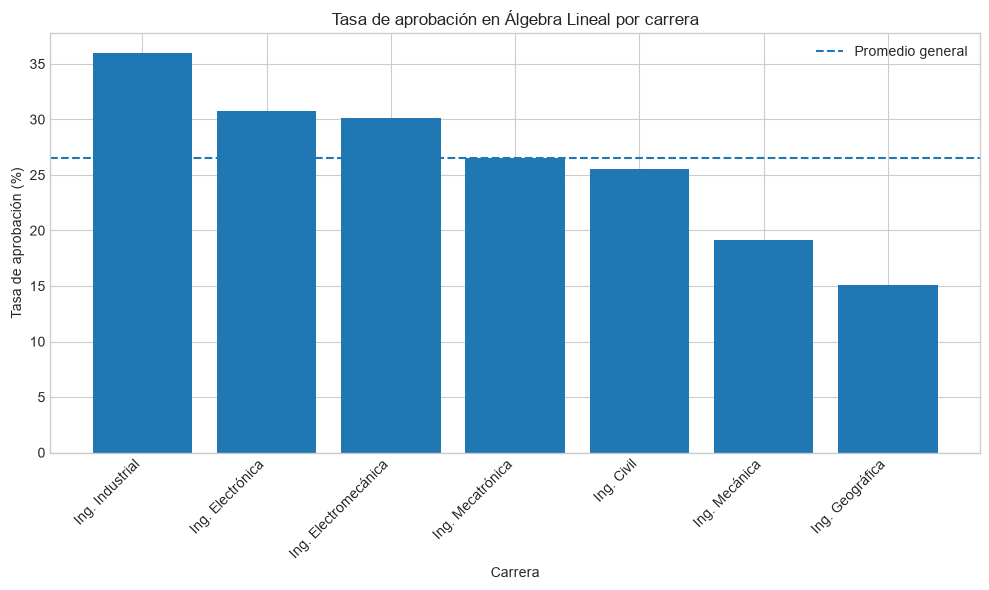

In [69]:
# =============================================================================
# 6.4. GRÁFICO: TASA DE APROBACIÓN POR CARRERA
# =============================================================================

plt.figure(figsize=(10, 6))

plt.bar(
    tabla_carrera['Carrera_Nombre'],
    tabla_carrera['Tasa_Aprobacion']
)

plt.axhline(
    df_algebra_lineal['Aprobado'].mean() * 100,
    linestyle='--',
    label='Promedio general'
)

plt.xlabel('Carrera')
plt.ylabel('Tasa de aprobación (%)')
plt.title('Tasa de aprobación en Álgebra Lineal por carrera')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# =============================================================================
# 7. SISTEMA DE ALERTA TEMPRANA
# =============================================================================

df_alerta = df_algebra_lineal.copy()

# Variables utilizadas por el modelo logístico
X_alerta = df_alerta[features].copy()

# Probabilidad estimada de aprobación
df_alerta['Probabilidad_Aprobacion'] = (
    modelo_logistico.predict_proba(X_alerta)[:, 1]
)

print("=" * 70)
print("PROBABILIDADES DE APROBACIÓN")
print("=" * 70)

print(
    df_alerta['Probabilidad_Aprobacion']
    .describe()
)

PROBABILIDADES DE APROBACIÓN
count    1980.000000
mean        0.382247
std         0.356198
min         0.000537
25%         0.035848
50%         0.271348
75%         0.729699
max         0.998659
Name: Probabilidad_Aprobacion, dtype: float64


In [71]:
df_alerta['Nivel_Riesgo'] = pd.cut(
    df_alerta['Probabilidad_Aprobacion'],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=[
        'Alto riesgo',
        'Riesgo medio',
        'Bajo riesgo'
    ]
)

print("=" * 70)
print("DISTRIBUCIÓN DE ESTUDIANTES POR NIVEL DE RIESGO")
print("=" * 70)

print(
    df_alerta['Nivel_Riesgo']
    .value_counts()
    .sort_index()
)

DISTRIBUCIÓN DE ESTUDIANTES POR NIVEL DE RIESGO
Nivel_Riesgo
Alto riesgo     1151
Riesgo medio     291
Bajo riesgo      538
Name: count, dtype: int64


In [72]:
tabla_riesgo = (
    df_alerta
    .groupby('Nivel_Riesgo', observed=False)
    .agg(
        Estudiantes=('ALUMNO_ID', 'count'),
        Tasa_Aprobacion_Real=('Aprobado', 'mean'),
        Promedio_Firma=('Firma', 'mean'),
        Promedio_Parciales=('Promedio_Parciales', 'mean')
    )
    .reset_index()
)

tabla_riesgo['Tasa_Aprobacion_Real'] *= 100

print("=" * 80)
print("VALIDACIÓN DE NIVELES DE RIESGO")
print("=" * 80)

print(
    tabla_riesgo.round(2).to_string(index=False)
)

VALIDACIÓN DE NIVELES DE RIESGO
Nivel_Riesgo  Estudiantes  Tasa_Aprobacion_Real  Promedio_Firma  Promedio_Parciales
 Alto riesgo         1151                  2.61           13.54               21.51
Riesgo medio          291                 46.74           45.50               46.09
 Bajo riesgo          538                 66.91           64.18               64.27


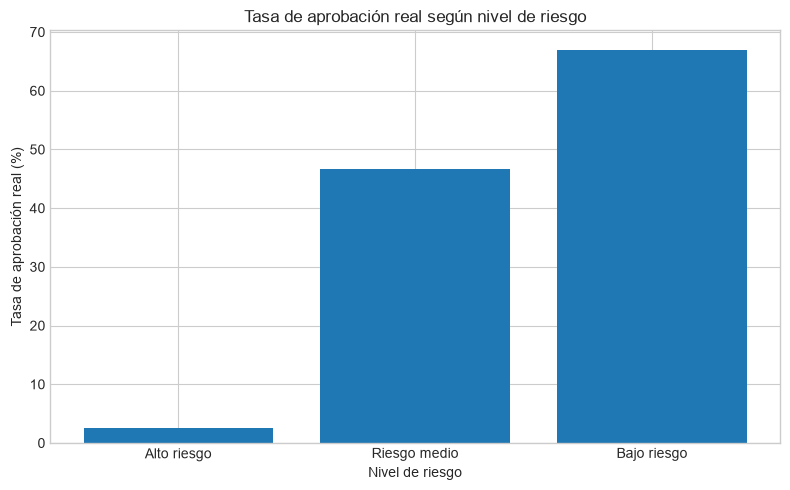

In [73]:
plt.figure(figsize=(8, 5))

plt.bar(
    tabla_riesgo['Nivel_Riesgo'].astype(str),
    tabla_riesgo['Tasa_Aprobacion_Real']
)

plt.ylabel('Tasa de aprobación real (%)')
plt.xlabel('Nivel de riesgo')
plt.title('Tasa de aprobación real según nivel de riesgo')
plt.tight_layout()
plt.show()